# 상위20% 위축 예측 — 인코딩

`h4_shrink_feature_table_raw.csv`(피처 엔지니어링 노트북의 산출물)를 불러와서 모델에 넣을 수 있는 숫자 행렬로 변환한다.

**방침 (확정된 것)**
- 인구통계 결측(180명)은 6개 컬럼에 동시에 나타나므로, `has_demo`(보유 여부) 이진 변수 1개로 따로 표시하고
  나머지 순서형·명목형 컬럼은 최빈값으로 대체 후 인코딩 (중복 표시 방지)
- 순서형(AGE_DESC, INCOME_DESC, HOUSEHOLD_SIZE_DESC, KID_CATEGORY_DESC): 순서를 살린 정수 인코딩
- 명목형(HOMEOWNER_DESC, HH_COMP_DESC): 원-핫 인코딩, 기준범주는 **최빈값**으로 지정
  (HH_COMP_DESC의 "Unknown"은 대가족 등 비전형 가구를 대리할 수 있어 기준범주로 쓰지 않고 독립 카테고리로 유지)


In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

feature_table = pd.read_csv("h4_shrink_feature_table_raw.csv", index_col=0)
feature_table.index.name = "HOUSEHOLD_KEY"
print(f"원본 shape: {feature_table.shape}")
feature_table.head()


원본 shape: (499, 12)


,sales_early,n_baskets,avg_items_per_basket,category_diversity,exposure_ratio,AGE_DESC,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,label_shrink
HOUSEHOLD_KEY,,,,,,,,,,,,
232,2426.34,159,5.672956,144,0.226164,35-44,35-49K,Unknown,2 Adults No Kids,2,None/Unknown,1
2318,2596.66,91,9.021978,120,0.237515,19-24,Under 15K,Unknown,Single Female,1,None/Unknown,1
697,686.07,9,27.444444,79,0.105263,정보없음,정보없음,정보없음,정보없음,정보없음,정보없음,1
1804,1335.60,46,6.760870,106,0.212219,65+,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,0
510,1149.80,35,13.457143,114,0.178344,35-44,250K+,Homeowner,2 Adults Kids,3,1,0


## 1. 인구통계 보유 여부(has_demo) 분리

180명은 6개 인구통계 컬럼 모두 "정보없음"으로 동시에 채워져 있으므로, 그 자체를 이진 변수 하나로 뽑아낸다.


In [2]:
demo_cols = ["AGE_DESC", "INCOME_DESC", "HOMEOWNER_DESC", "HH_COMP_DESC",
             "HOUSEHOLD_SIZE_DESC", "KID_CATEGORY_DESC"]

# 6개 컬럼 모두 "정보없음"인 행이 전부 같은 180명인지 확인
missing_mask = (feature_table[demo_cols] == "정보없음").all(axis=1)
print(f"6개 컬럼 모두 '정보없음'인 가구 수: {missing_mask.sum()}")
print(f"일부만 '정보없음'인 가구 수(있으면 안 됨): {((feature_table[demo_cols] == '정보없음').any(axis=1) & ~missing_mask).sum()}")

feature_table["has_demo"] = (~missing_mask).astype(int)
print("\nhas_demo 분포")
print(feature_table["has_demo"].value_counts())


6개 컬럼 모두 '정보없음'인 가구 수: 180
일부만 '정보없음'인 가구 수(있으면 안 됨): 0

has_demo 분포
has_demo
1    319
0    180
Name: count, dtype: int64


## 2. 순서형 인코딩 (AGE_DESC, INCOME_DESC, HOUSEHOLD_SIZE_DESC, KID_CATEGORY_DESC)

"정보없음"은 각 컬럼의 최빈값(정보없음 제외하고 계산)으로 대체한 뒤 순서형 매핑.


In [3]:
ordinal_maps = {
    "AGE_DESC": ["19-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    "INCOME_DESC": ["Under 15K", "15-24K", "25-34K", "35-49K", "50-74K", "75-99K",
                    "100-124K", "125-149K", "150-174K", "175-199K", "200-249K", "250K+"],
    "HOUSEHOLD_SIZE_DESC": ["1", "2", "3", "4", "5+"],
    "KID_CATEGORY_DESC": ["None/Unknown", "1", "2", "3+"],
}

for col, order in ordinal_maps.items():
    non_missing = feature_table.loc[feature_table[col] != "정보없음", col]
    mode_val = non_missing.mode()[0]
    print(f"{col}: 결측 대체용 최빈값 = '{mode_val}'")

    filled = feature_table[col].replace("정보없음", mode_val)

    # 매핑 정의에 없는 값이 있는지 확인 (오타/누락 방지)
    unexpected = set(filled.unique()) - set(order)
    if unexpected:
        print(f"  ⚠ 매핑 목록에 없는 값 발견: {unexpected} — order 리스트 확인 필요")

    code_map = {v: i for i, v in enumerate(order)}
    feature_table[col + "_encoded"] = filled.map(code_map)

feature_table[[c + "_encoded" for c in ordinal_maps.keys()]].describe()


AGE_DESC: 결측 대체용 최빈값 = '45-54'
INCOME_DESC: 결측 대체용 최빈값 = '50-74K'
HOUSEHOLD_SIZE_DESC: 결측 대체용 최빈값 = '2'
KID_CATEGORY_DESC: 결측 대체용 최빈값 = 'None/Unknown'


,AGE_DESC_encoded,INCOME_DESC_encoded,HOUSEHOLD_SIZE_DESC_encoded,KID_CATEGORY_DESC_encoded
count,499.000000,499.000000,499.000000,499.000000
mean,2.623246,4.066132,1.176353,0.384770
std,0.966477,1.963941,0.965760,0.840879
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,3.000000,1.000000,0.000000
50%,3.000000,4.000000,1.000000,0.000000
75%,3.000000,4.000000,1.000000,0.000000
max,5.000000,11.000000,4.000000,3.000000


## 3. 명목형 원-핫 인코딩 (HOMEOWNER_DESC, HH_COMP_DESC)

기준범주(reference)는 최빈값으로 지정하고, 원-핫 인코딩 후 기준범주 컬럼은 제거(drop).
HH_COMP_DESC의 "Unknown"은 기준범주로 쓰지 않고 독립 카테고리로 유지 — 대가족 등 비전형 가구 신호 보존 목적.


In [4]:
def one_hot_with_reference(series, reference=None):
    filled = series.replace("정보없음", series[series != "정보없음"].mode()[0])
    if reference is None:
        reference = filled.mode()[0]
    dummies = pd.get_dummies(filled, prefix=series.name).astype(int)
    ref_col = f"{series.name}_{reference}"
    print(f"{series.name}: 기준범주(제거됨) = '{reference}'")
    return dummies.drop(columns=[ref_col]), reference

homeowner_dummies, homeowner_ref = one_hot_with_reference(feature_table["HOMEOWNER_DESC"])
hhcomp_dummies, hhcomp_ref = one_hot_with_reference(feature_table["HH_COMP_DESC"], reference="2 Adults No Kids")

print(f"\nHOMEOWNER_DESC 더미 컬럼: {list(homeowner_dummies.columns)}")
print(f"HH_COMP_DESC 더미 컬럼: {list(hhcomp_dummies.columns)}")


HOMEOWNER_DESC: 기준범주(제거됨) = 'Homeowner'
HH_COMP_DESC: 기준범주(제거됨) = '2 Adults No Kids'

HOMEOWNER_DESC 더미 컬럼: ['HOMEOWNER_DESC_Probable Owner', 'HOMEOWNER_DESC_Probable Renter', 'HOMEOWNER_DESC_Renter', 'HOMEOWNER_DESC_Unknown']
HH_COMP_DESC 더미 컬럼: ['HH_COMP_DESC_1 Adult Kids', 'HH_COMP_DESC_2 Adults Kids', 'HH_COMP_DESC_Single Female', 'HH_COMP_DESC_Single Male', 'HH_COMP_DESC_Unknown']


## 4. 최종 인코딩 테이블 조합

In [5]:
numeric_cols = ["sales_early", "n_baskets", "avg_items_per_basket", "category_diversity", "exposure_ratio"]
ordinal_encoded_cols = [c + "_encoded" for c in ordinal_maps.keys()]

encoded_table = pd.concat([
    feature_table[numeric_cols],
    feature_table[["has_demo"]],
    feature_table[ordinal_encoded_cols],
    homeowner_dummies,
    hhcomp_dummies,
    feature_table[["label_shrink"]],
], axis=1)

print(f"최종 인코딩 테이블 shape: {encoded_table.shape}")
print(f"\n전체 컬럼 목록 ({len(encoded_table.columns)}개):")
print(list(encoded_table.columns))

print("\ndtypes 확인 (전부 숫자형이어야 함)")
print(encoded_table.dtypes)


최종 인코딩 테이블 shape: (499, 20)

전체 컬럼 목록 (20개):
['sales_early', 'n_baskets', 'avg_items_per_basket', 'category_diversity', 'exposure_ratio', 'has_demo', 'AGE_DESC_encoded', 'INCOME_DESC_encoded', 'HOUSEHOLD_SIZE_DESC_encoded', 'KID_CATEGORY_DESC_encoded', 'HOMEOWNER_DESC_Probable Owner', 'HOMEOWNER_DESC_Probable Renter', 'HOMEOWNER_DESC_Renter', 'HOMEOWNER_DESC_Unknown', 'HH_COMP_DESC_1 Adult Kids', 'HH_COMP_DESC_2 Adults Kids', 'HH_COMP_DESC_Single Female', 'HH_COMP_DESC_Single Male', 'HH_COMP_DESC_Unknown', 'label_shrink']

dtypes 확인 (전부 숫자형이어야 함)
sales_early                       float64
n_baskets                           int64
avg_items_per_basket              float64
category_diversity                  int64
exposure_ratio                    float64
has_demo                            int64
AGE_DESC_encoded                    int64
INCOME_DESC_encoded                 int64
HOUSEHOLD_SIZE_DESC_encoded         int64
KID_CATEGORY_DESC_encoded           int64
HOMEOWNER_DESC_Probable Own

In [6]:
# 결측 최종 확인
print("결측치 확인 (전부 0이어야 함)")
print(encoded_table.isna().sum().sum())

encoded_table.head()


결측치 확인 (전부 0이어야 함)
0


,sales_early,n_baskets,avg_items_per_basket,category_diversity,exposure_ratio,has_demo,AGE_DESC_encoded,INCOME_DESC_encoded,HOUSEHOLD_SIZE_DESC_encoded,KID_CATEGORY_DESC_encoded,HOMEOWNER_DESC_Probable Owner,HOMEOWNER_DESC_Probable Renter,HOMEOWNER_DESC_Renter,HOMEOWNER_DESC_Unknown,HH_COMP_DESC_1 Adult Kids,HH_COMP_DESC_2 Adults Kids,HH_COMP_DESC_Single Female,HH_COMP_DESC_Single Male,HH_COMP_DESC_Unknown,label_shrink
HOUSEHOLD_KEY,,,,,,,,,,,,,,,,,,,,
232,2426.34,159,5.672956,144,0.226164,1,2,3,1,0,0,0,0,1,0,0,0,0,0,1
2318,2596.66,91,9.021978,120,0.237515,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1
697,686.07,9,27.444444,79,0.105263,0,3,4,1,0,0,0,0,0,0,0,0,0,0,1
1804,1335.60,46,6.760870,106,0.212219,1,5,3,1,0,0,0,0,0,0,0,0,0,0,0
510,1149.80,35,13.457143,114,0.178344,1,2,11,2,1,0,0,0,0,0,1,0,0,0,0


## 5. 저장 (다음 단계: VIF 확인 → 모델링)

In [7]:
encoded_table.to_csv("h4_shrink_feature_table_encoded.csv")
print("저장 완료: h4_shrink_feature_table_encoded.csv")
print(f"shape: {encoded_table.shape}")

feature_cols_only = [c for c in encoded_table.columns if c != "label_shrink"]
print(f"\n모델에 쓸 최종 feature 개수: {len(feature_cols_only)}개")
print(f"소수 클래스(위축=1) 표본 수: {(encoded_table['label_shrink']==1).sum()}")
print(f"EPV(class당 표본/feature수) 참고치: {(encoded_table['label_shrink']==1).sum() / len(feature_cols_only):.1f}")


저장 완료: h4_shrink_feature_table_encoded.csv
shape: (499, 20)

모델에 쓸 최종 feature 개수: 19개
소수 클래스(위축=1) 표본 수: 223
EPV(class당 표본/feature수) 참고치: 11.7


# VIF 확인

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

encoded_table = pd.read_csv("h4_shrink_feature_table_encoded.csv", index_col=0)

feature_cols = [c for c in encoded_table.columns if c != "label_shrink"]
X = encoded_table[feature_cols].copy()

# VIF 계산엔 상수항(intercept)이 필요 — 계산 후 제외
X_with_const = add_constant(X)

vif_data = pd.DataFrame({
    "feature": X_with_const.columns,
    "VIF": [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
})

# 상수항 행 제외하고 VIF 큰 순으로 정렬
vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_data)

                           feature        VIF
0        KID_CATEGORY_DESC_encoded  26.678552
1      HOUSEHOLD_SIZE_DESC_encoded  26.493765
2       HH_COMP_DESC_2 Adults Kids   4.762398
3        HH_COMP_DESC_1 Adult Kids   2.984301
4       HH_COMP_DESC_Single Female   2.724263
5         HH_COMP_DESC_Single Male   2.691699
6               category_diversity   2.389632
7                      sales_early   2.371222
8                        n_baskets   2.276969
9             HH_COMP_DESC_Unknown   2.183555
10            avg_items_per_basket   1.894525
11                        has_demo   1.842807
12          HOMEOWNER_DESC_Unknown   1.542660
13                AGE_DESC_encoded   1.289744
14             INCOME_DESC_encoded   1.240858
15           HOMEOWNER_DESC_Renter   1.227302
16                  exposure_ratio   1.122729
17  HOMEOWNER_DESC_Probable Renter   1.063133
18   HOMEOWNER_DESC_Probable Owner   1.062583


In [9]:
# 판단 기준
# VIF < 5   : 문제없음
# VIF 5~10  : 주의 (다중공선성 있을 수 있음)
# VIF > 10  : 심각 (해당 feature 제거 또는 관련 feature 통합 고려)

print("\n주의/심각 수준 feature")
print(vif_data[vif_data["VIF"] >= 5])

n_concern = (vif_data["VIF"] >= 5).sum()
n_severe = (vif_data["VIF"] >= 10).sum()
print(f"\nVIF≥5 (주의): {n_concern}개")
print(f"VIF≥10 (심각): {n_severe}개")


주의/심각 수준 feature
                       feature        VIF
0    KID_CATEGORY_DESC_encoded  26.678552
1  HOUSEHOLD_SIZE_DESC_encoded  26.493765

VIF≥5 (주의): 2개
VIF≥10 (심각): 2개


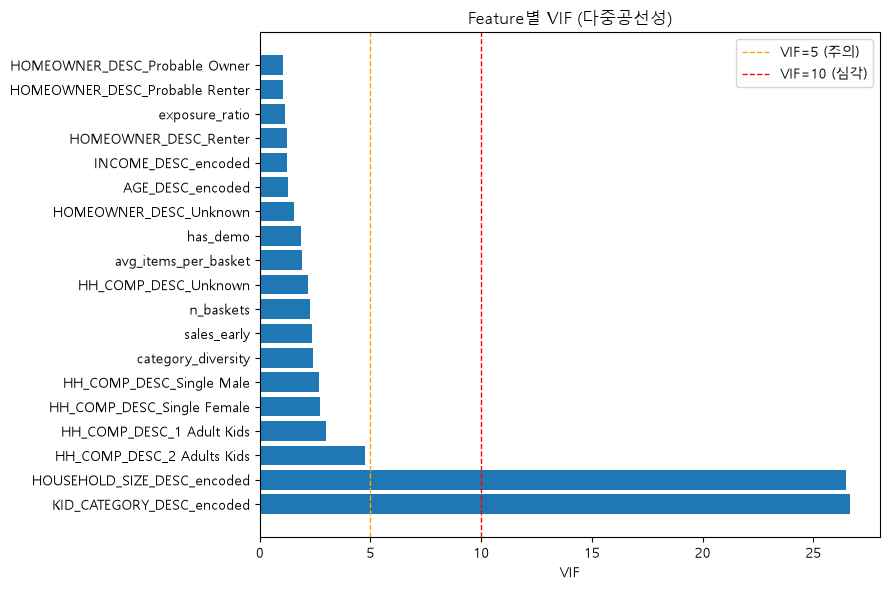

In [12]:
# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(vif_data["feature"], vif_data["VIF"])
ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='VIF=5 (주의)')
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='VIF=10 (심각)')
ax.set_xlabel("VIF")
ax.set_title("Feature별 VIF (다중공선성)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
feature_cols_final = [c for c in feature_cols if c != "KID_CATEGORY_DESC_encoded"]

X_final = encoded_table[feature_cols_final]
X_final_const = add_constant(X_final)

vif_final = pd.DataFrame({
    "feature": X_final_const.columns,
    "VIF": [variance_inflation_factor(X_final_const.values, i) for i in range(X_final_const.shape[1])]
})
vif_final = vif_final[vif_final["feature"] != "const"].sort_values("VIF", ascending=False)
print(vif_final)

                           feature       VIF
9      HOUSEHOLD_SIZE_DESC_encoded  4.814787
15      HH_COMP_DESC_2 Adults Kids  4.019727
4               category_diversity  2.380506
1                      sales_early  2.370205
2                        n_baskets  2.275265
3             avg_items_per_basket  1.893916
6                         has_demo  1.841084
16      HH_COMP_DESC_Single Female  1.684571
14       HH_COMP_DESC_1 Adult Kids  1.602820
17        HH_COMP_DESC_Single Male  1.571883
13          HOMEOWNER_DESC_Unknown  1.515187
18            HH_COMP_DESC_Unknown  1.356165
7                 AGE_DESC_encoded  1.282913
8              INCOME_DESC_encoded  1.240645
12           HOMEOWNER_DESC_Renter  1.215890
5                   exposure_ratio  1.119114
10   HOMEOWNER_DESC_Probable Owner  1.060970
11  HOMEOWNER_DESC_Probable Renter  1.057826
